In [1]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
X_train = np.load('./X_train.npy')
y_train = np.load('./y_train.npy')
X_test = np.load('./X_test.npy')
y_test = np.load('./y_test.npy')
scaler = StandardScaler()
scaler.fit(X_train, y_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'solver': ['lbfgs', 'newton-cg', 'newton-cholesky'],
    'max_iter': randint(100, 5000),
}

search = RandomizedSearchCV(
    LogisticRegression(),
    param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
)

search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f9385385350>,
                                        'solver': ['lbfgs', 'newton-cg',
                                                   'newton-cholesky']},
                   random_state=42)

In [4]:
best_logistic_reg = search.best_estimator_
best_logistic_reg.fit(X_train, y_train)
accuracy_score(y_test, best_logistic_reg.predict(X_test))

0.352

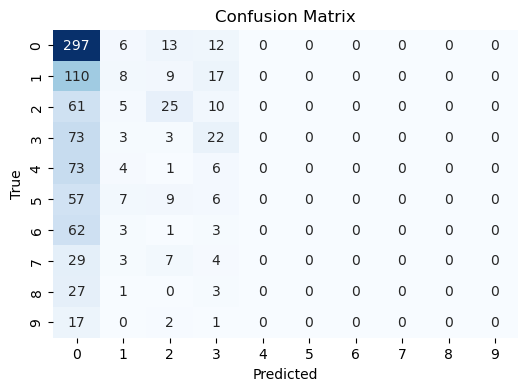

In [5]:
conf_matrix = confusion_matrix(y_test, best_logistic_reg.predict(X_test))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()